In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
accident_path = "../Accident_Information.csv"
vehicle_path = "../Vehicle_Information.csv"

In [4]:
accident_df = pd.read_csv(accident_path, low_memory=False)
vehicle_df = pd.read_csv(vehicle_path, encoding="latin1", low_memory=False)

In [5]:
print("Accident data:", accident_df.shape)
print("Vehicle data:", vehicle_df.shape)

Accident data: (2047256, 34)
Vehicle data: (2177205, 24)


## Dataset Overview

This project analyzes UK road safety data from 2005–2017. The dataset contains two related files: accident-level information and vehicle-level information. The two datasets can be linked using `Accident_Index`.

The accident dataset contains 2,047,256 records and 34 variables, while the vehicle dataset contains 2,177,205 records and 24 variables.

In [6]:
accident_df.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [7]:
accident_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               str    
 1   1st_Road_Class                               str    
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               str    
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            str    
 6   Carriageway_Hazards                          str    
 7   Date                                         str    
 8   Day_of_Week                                  str    
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             str    
 11  Junction_Detail                              str    
 12  Latitude                                     float64
 13  Light_Conditions       

In [8]:
vehicle_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2177205 entries, 0 to 2177204
Data columns (total 24 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Accident_Index                    str    
 1   Age_Band_of_Driver                str    
 2   Age_of_Vehicle                    float64
 3   Driver_Home_Area_Type             str    
 4   Driver_IMD_Decile                 float64
 5   Engine_Capacity_.CC.              float64
 6   Hit_Object_in_Carriageway         str    
 7   Hit_Object_off_Carriageway        str    
 8   Journey_Purpose_of_Driver         str    
 9   Junction_Location                 str    
 10  make                              str    
 11  model                             str    
 12  Propulsion_Code                   str    
 13  Sex_of_Driver                     str    
 14  Skidding_and_Overturning          str    
 15  Towing_and_Articulation           str    
 16  Vehicle_Leaving_Carriageway       str    
 17  

## Data Types and Structure

The `info()` output was used to review the structure of both datasets, including the number of entries, column names, data types, and non-null values. This helps identify variables that may require conversion or preprocessing before modeling.

In [9]:
accident_df.isna().sum().sort_values(ascending=False)

Carriageway_Hazards                            2007807
Special_Conditions_at_Site                     1995137
2nd_Road_Class                                  844272
LSOA_of_Accident_Location                       144953
2nd_Road_Number                                  17593
Pedestrian_Crossing-Physical_Facilities           3560
Pedestrian_Crossing-Human_Control                 2920
Did_Police_Officer_Attend_Scene_of_Accident        278
Longitude                                          175
Latitude                                           174
Location_Easting_OSGR                              164
Location_Northing_OSGR                             164
Time                                               156
InScotland                                          53
Speed_limit                                         37
1st_Road_Number                                      2
1st_Road_Class                                       0
Accident_Index                                       0
Local_Auth

In [10]:
vehicle_df.isna().sum().sort_values(ascending=False)

Hit_Object_in_Carriageway           2087824
Hit_Object_off_Carriageway          1989741
Skidding_and_Overturning            1898208
Driver_IMD_Decile                    734812
Age_of_Vehicle                       358149
model                                325331
Engine_Capacity_.CC.                 265861
Propulsion_Code                      245843
make                                 110845
Vehicle_Location.Restricted_Lane       1317
Driver_Home_Area_Type                     0
Accident_Index                            0
Age_Band_of_Driver                        0
Journey_Purpose_of_Driver                 0
Sex_of_Driver                             0
Junction_Location                         0
Towing_and_Articulation                   0
Vehicle_Leaving_Carriageway               0
Vehicle_Manoeuvre                         0
Vehicle_Reference                         0
Vehicle_Type                              0
Was_Vehicle_Left_Hand_Drive               0
X1st_Point_of_Impact            

## Missing Values

Missing-value counts were reviewed for both datasets to identify variables that may require attention during preprocessing. These results will guide later decisions about whether to remove, impute, or otherwise handle missing observations.

In [11]:
accident_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Accident_Index,2047256,2047256,200501BS00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1st_Road_Class,2047256,6,A,926729,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1st_Road_Number,2047254.0,NaN,NaN,NaN,992.105099,1809.407936,0.0,0.0,118.0,702.0,9999.0
2nd_Road_Class,1202984,6,Unclassified,814983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd_Road_Number,2029663.0,NaN,NaN,NaN,372.815342,1287.796383,0.0,0.0,0.0,0.0,9999.0
Accident_Severity,2047256,3,Slight,1734548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carriageway_Hazards,39449,6,Other object on road,16111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,2047256,4748,2005-10-21,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,2047256,7,Friday,335183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Did_Police_Officer_Attend_Scene_of_Accident,2046978.0,NaN,NaN,NaN,1.202319,0.408194,1.0,1.0,1.0,1.0,3.0


In [12]:
vehicle_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Accident_Index,2177205,1488981,2013460234852,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_Band_of_Driver,2177205,12,26 - 35,450531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_of_Vehicle,1819056.0,NaN,NaN,NaN,7.108167,4.725886,1.0,3.0,7.0,10.0,111.0
Driver_Home_Area_Type,2177205,4,Urban area,1436598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_IMD_Decile,1442393.0,NaN,NaN,NaN,5.387559,2.821651,1.0,3.0,5.0,8.0,10.0
Engine_Capacity_.CC.,1911344.0,NaN,NaN,NaN,2042.233961,1950.14317,1.0,1299.0,1598.0,1997.0,96000.0
Hit_Object_in_Carriageway,89381,12,Kerb,34354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hit_Object_off_Carriageway,187464,12,Other permanent object,56640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Journey_Purpose_of_Driver,2177205,8,Not known,834626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Junction_Location,2177205,10,Not at or within 20 metres of junction,808108,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Descriptive Statistics

Descriptive statistics were reviewed for the accident and vehicle datasets to understand the distributions and ranges of the available variables. This provides an initial view of numerical and categorical characteristics before preprocessing and modeling.

In [13]:
accident_df["Accident_Severity"].value_counts(dropna=False)

Accident_Severity
Slight     1734548
Serious     286339
Fatal        26369
Name: count, dtype: int64

In [14]:
accident_df["Year"].value_counts().sort_index()

Year
2005    198735
2006    189161
2007    182115
2008    170591
2009    163554
2010    154414
2011    151474
2012    145571
2013    138660
2014    146322
2015    140056
2016    136621
2017    129982
Name: count, dtype: int64

In [15]:
accident_df["Number_of_Casualties"].describe()

count    2.047256e+06
mean     1.345843e+00
std      8.179627e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.300000e+01
Name: Number_of_Casualties, dtype: float64

## Accident Severity and Casualties

The analysis examines accident severity and the number of casualties to understand whether more severe accidents are associated with a greater number of casualties. This relationship may help identify useful variables for later modeling.

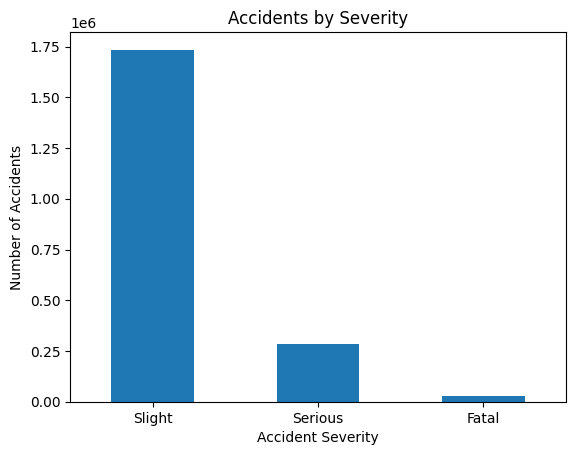

In [16]:
accident_df["Accident_Severity"].value_counts().plot(kind="bar")
plt.title("Accidents by Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)
plt.show()

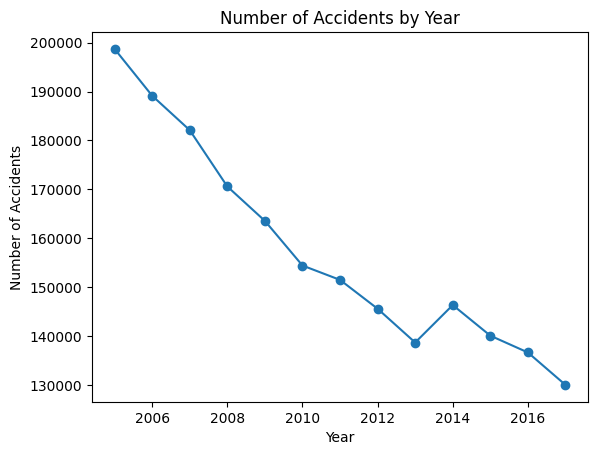

In [17]:
accident_df.groupby("Year").size().plot(kind="line", marker="o")
plt.title("Number of Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

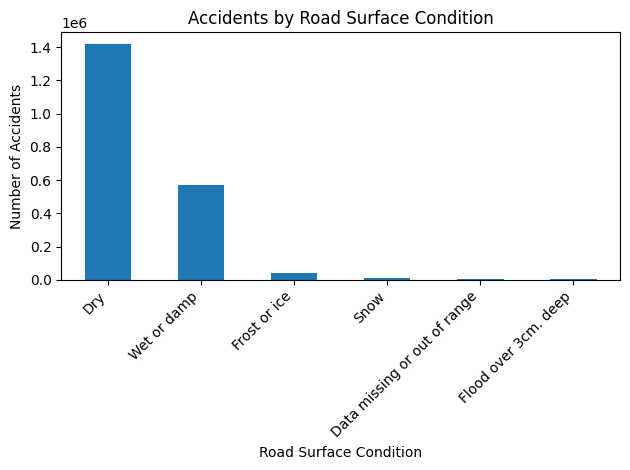

In [18]:
accident_df["Road_Surface_Conditions"].value_counts().head(10).plot(kind="bar")
plt.title("Accidents by Road Surface Condition")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Environmental Conditions

Road surface and weather conditions were explored to understand how environmental factors are represented in the accident data. These variables may provide useful context for explaining differences in accident severity and can be considered during later feature selection.

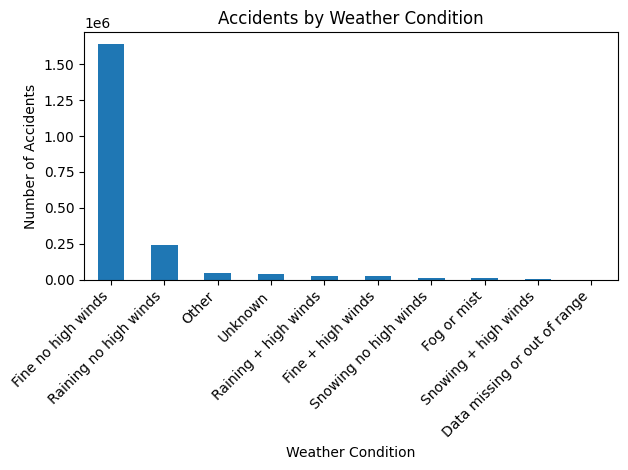

In [19]:
accident_df["Weather_Conditions"].value_counts().head(10).plot(kind="bar")
plt.title("Accidents by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

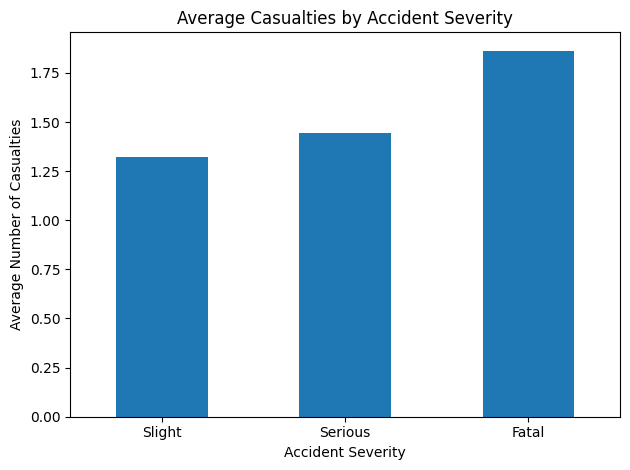

In [20]:
accident_df.groupby("Accident_Severity")["Number_of_Casualties"].mean().sort_values().plot(kind="bar")
plt.title("Average Casualties by Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Average Number of Casualties")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

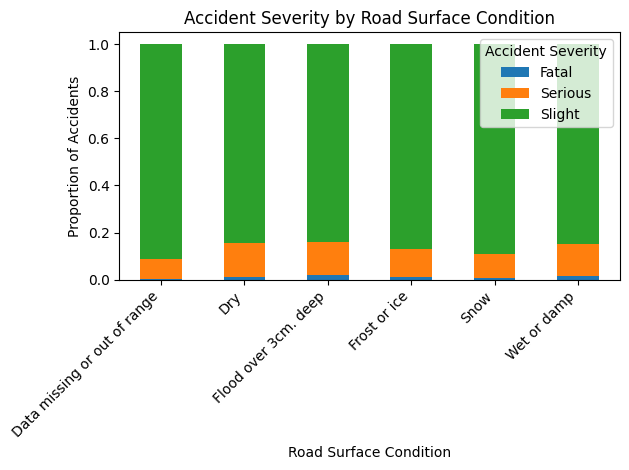

In [21]:
pd.crosstab(
    accident_df["Road_Surface_Conditions"],
    accident_df["Accident_Severity"],
    normalize="index"
).plot(kind="bar", stacked=True)

plt.title("Accident Severity by Road Surface Condition")
plt.xlabel("Road Surface Condition")
plt.ylabel("Proportion of Accidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Accident Severity")
plt.tight_layout()
plt.show()

## Relationship Between Road Conditions and Severity

The relationship between road surface conditions and accident severity was explored using proportions within each road-surface category. This provides an initial comparison of severity patterns across different road conditions.

In [22]:
print("Accident duplicate rows:", accident_df.duplicated().sum())
print("Vehicle duplicate rows:", vehicle_df.duplicated().sum())
print("Accident missing cells:", accident_df.isna().sum().sum())
print("Vehicle missing cells:", vehicle_df.isna().sum().sum())

Accident duplicate rows: 0
Vehicle duplicate rows: 0
Accident missing cells: 5017445
Vehicle missing cells: 8017931


## Data Quality Check

Duplicate records and total missing cells were checked as part of the initial data-quality assessment. These results will be used to guide preprocessing decisions before any machine-learning models are developed.

In [23]:
print("Initial EDA completed.")
print(f"Accident records: {len(accident_df):,}")
print(f"Vehicle records: {len(vehicle_df):,}")
print(f"Accident columns: {accident_df.shape[1]}")
print(f"Vehicle columns: {vehicle_df.shape[1]}")

Initial EDA completed.
Accident records: 2,047,256
Vehicle records: 2,177,205
Accident columns: 34
Vehicle columns: 24


## Initial EDA Conclusion

The initial exploratory analysis examined the structure, completeness, distributions, time patterns, accident severity, casualties, road surface conditions, and weather conditions in the UK road safety data.

The EDA provides a foundation for the next stage of the project: preprocessing and feature selection. The results will be discussed with the team before deciding which variables and relationships should be carried forward into unsupervised and supervised modeling.